In [1]:
# =============================================
# БЛОК 1: УСТАНОВКА БИБЛИОТЕК
# =============================================

# Устанавливаем все необходимые библиотеки для проекта
!pip install flaml[automl] optuna hyperopt xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn plotly scipy shap --quiet

# Импортируем библиотеки для работы
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки импортированы успешно")

Все библиотеки импортированы успешно


In [2]:
# =============================================
# БЛОК 2: ЗАГРУЗКА ДАННЫХ
# =============================================
print("Нажмите кнопку 'Выберите файл' и загрузите ваш CSV-файл")

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
print(f"Загружен файл: {file_name}")

df = pd.read_csv(file_name)
print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} колонок")

print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о колонках:")
df.info()


Нажмите кнопку 'Выберите файл' и загрузите ваш CSV-файл


Saving Perfume_Market_Intelligence_Dataset.csv to Perfume_Market_Intelligence_Dataset (2).csv
Загружен файл: Perfume_Market_Intelligence_Dataset (2).csv
Данные загружены: 1998 строк, 17 колонок

Первые 5 строк:


,Brand,Product,Gender,Product_Type,Price,Sold,Available,Revenue_Potential,Demand_Score,Price_Category,Market_Segment,Sales_Performance,Brand_Popularity,Country,Inventory_Status,Stock_Turnover,Revenue_Rank
0,Paco Rabanne,Paco Rabanne Invictus 3.4 oz EDT Sporty Men's ...,Men,EDT,39.99,118.0,10.0,4718.82,94.597,Mid-Range,Premium,High Seller,High,United States,Medium Stock,Fast,Others
1,Lucianno,Lucianno California Vibe M 100ml Boxed,Men,Unknown,66.00,21.0,10.0,1386.00,34.500,Mid-Range,Premium,Medium Seller,Low,Canada,Medium Stock,Slow,Others
2,BHARARA,BHARARA KING PURE PARFUM BY BHARARA 3.4 FOR ME...,Men,Parfum,71.49,31.0,4.0,2216.19,43.147,Mid-Range,Premium,Medium Seller,Low,United States,Low Stock,Fast,Others
3,Branded,*Perfume Para Hombre Con Feromonas De Atraer M...,Men,Unknown,17.99,1.0,13.0,17.99,6.097,Budget,Mass Market,Low Seller,Low,United States,Medium Stock,Slow,Others
4,Thierry Mugler,Alien by Thierry Mugler 3 oz EDP Perfume for W...,Women,EDP,85.56,953.0,0.0,81538.68,692.768,Luxury,Luxury,High Seller,Medium,United States,Low Stock,Fast,Top 10%



Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              1996 non-null   object 
 1   Product            1998 non-null   object 
 2   Gender             1998 non-null   object 
 3   Product_Type       1998 non-null   object 
 4   Price              1998 non-null   float64
 5   Sold               1998 non-null   float64
 6   Available          1998 non-null   float64
 7   Revenue_Potential  1998 non-null   float64
 8   Demand_Score       1998 non-null   float64
 9   Price_Category     1998 non-null   object 
 10  Market_Segment     1998 non-null   object 
 11  Sales_Performance  1998 non-null   object 
 12  Brand_Popularity   1998 non-null   object 
 13  Country            1998 non-null   object 
 14  Inventory_Status   1998 non-null   object 
 15  Stock_Turnover     1998 non-null   object 
 16  

In [3]:
# =============================================
# БЛОК 3: ОПИСАНИЕ КОЛОНОК
# =============================================
print("\n" + "="*80)
print("ОПИСАНИЕ КОЛОНОК ДАТАСЕТА")
print("="*80)

target = 'Revenue_Potential'
print(f"\nЦелевая переменная: {target}\n")
print(f"{'Колонка':<25} {'Тип':<12} {'Уникальных':<10} {'Пропусков':<10} {'Min':<12} {'Max':<12} {'Среднее':<12} {'Примеры'}")
print("-"*120)

for col in df.columns:
    v = df[col]
    if v.dtype != 'object':
        print(f"{col:<25} {'Числовой':<15} {v.nunique():<10} {v.isnull().sum():<10} {v.min():<12.2f} {v.max():<12.2f} {v.mean():<12.2f} -")
    else:
        u = v.unique()
        print(f"{col:<25} {'Категориальный':<15} {len(u):<10} {v.isnull().sum():<10} {'-':<12} {'-':<12} {'-':<12} {', '.join(map(str, u[:5])) + ('...' if len(u) > 5 else '')}")

print("\n" + "="*80)


ОПИСАНИЕ КОЛОНОК ДАТАСЕТА

Целевая переменная: Revenue_Potential

Колонка                   Тип          Уникальных Пропусков  Min          Max          Среднее      Примеры
------------------------------------------------------------------------------------------------------------------------
Brand                     Категориальный  402        2          -            -            -            Paco Rabanne, Lucianno, BHARARA, Branded, Thierry Mugler...
Product                   Категориальный  1941       0          -            -            -            Paco Rabanne Invictus 3.4 oz EDT Sporty Men's Cologne Energizing Scent Sealed, Lucianno California Vibe M 100ml Boxed, BHARARA KING PURE PARFUM BY BHARARA 3.4 FOR MEN, new launch 2023, *Perfume Para Hombre Con Feromonas De Atraer Mujeres Fragancia Colonia Masculino, Alien by Thierry Mugler 3 oz EDP Perfume for Women New In Box...
Gender                    Категориальный  2          0          -            -            -            Men


АНАЛИЗ ДАННЫХ (EDA)


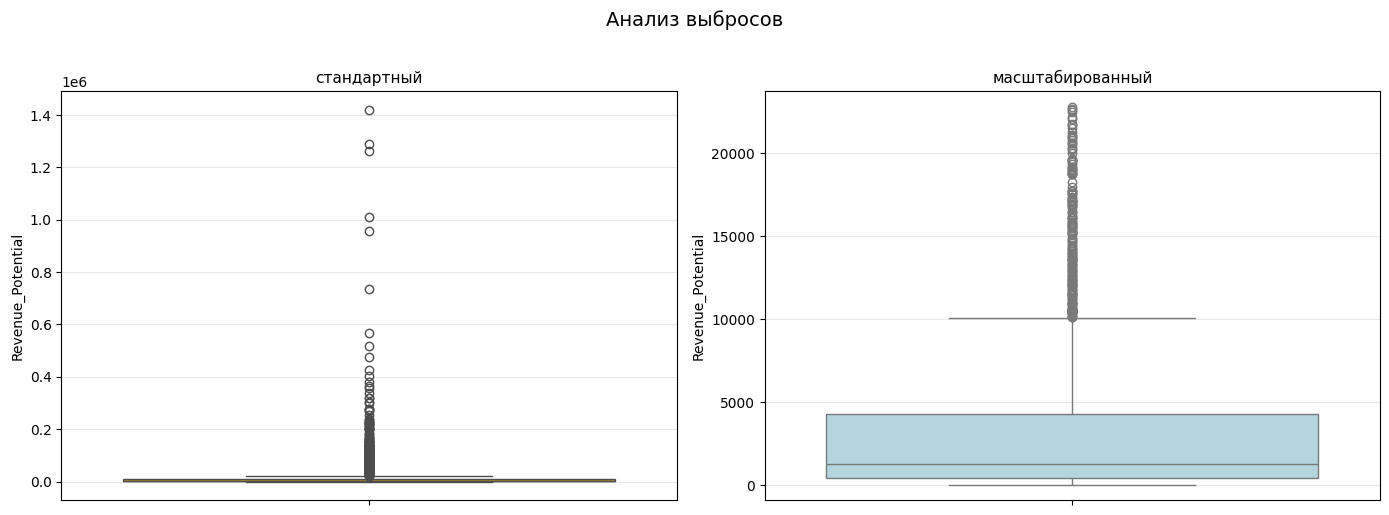

Медиана: 1811.52, Q1: 511.32, Q3: 9446.99, Выбросов: 294

ГИСТОГРАММА И МАТРИЦА КОРРЕЛЯЦИИ


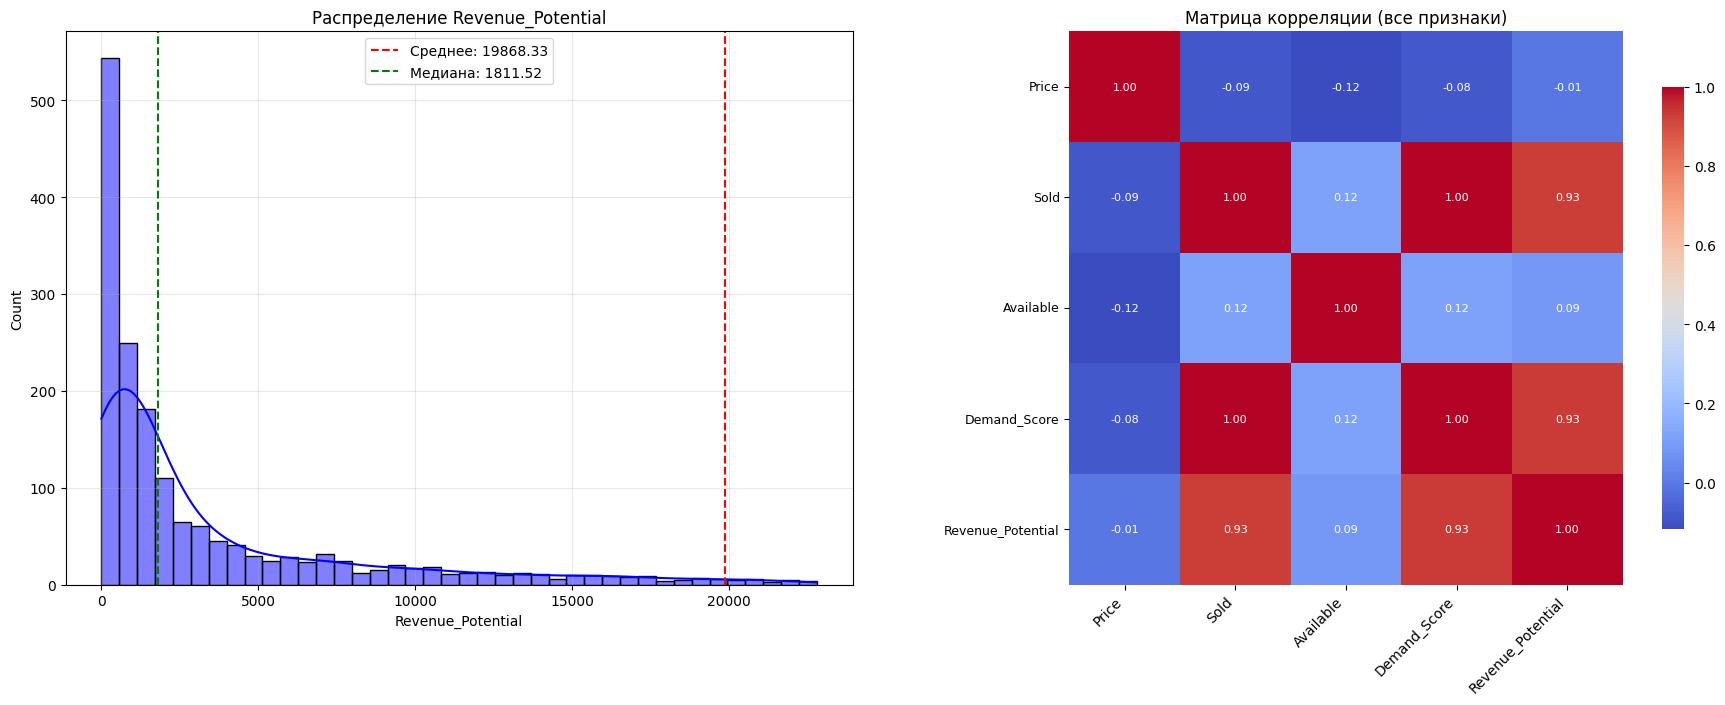


Влияние признаков на Revenue_Potential:
  1. Demand_Score: 0.930 (положительно)
  2. Sold: 0.930 (положительно)
  3. Available: 0.085 (положительно)
  4. Price: -0.008 (отрицательно)

ВИЗУАЛИЗАЦИЯ ВЗАИМОСВЯЗЕЙ
Найдено 2 признаков с сильной корреляцией:
  - Demand_Score: 0.930
  - Sold: 0.930


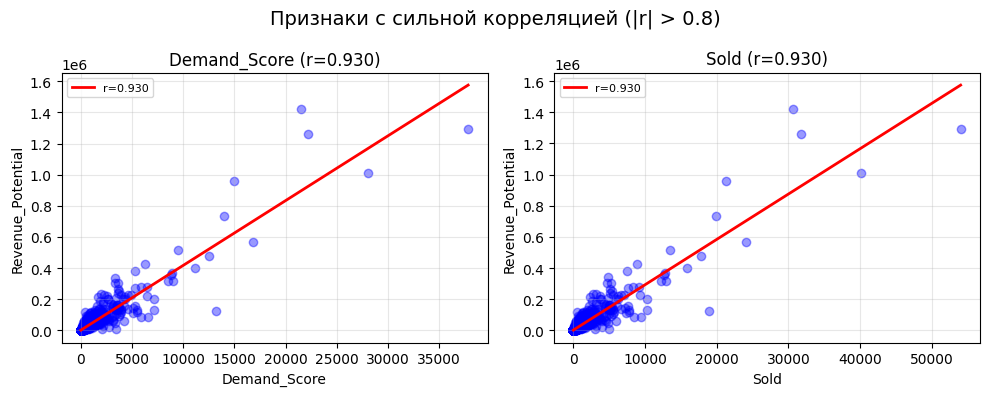


ВЫВОДЫ ПО СИЛЬНЫМ ВЗАИМОСВЯЗЯМ:
  Demand_Score (r=0.930): при росте признака доход увеличивается
  Sold (r=0.930): при росте признака доход увеличивается

СРАВНЕНИЕ СРЕДНЕГО ДОХОДА ПО КАТЕГОРИЯМ
Общее среднее: 19868.33 (красная линия)
--------------------------------------------------


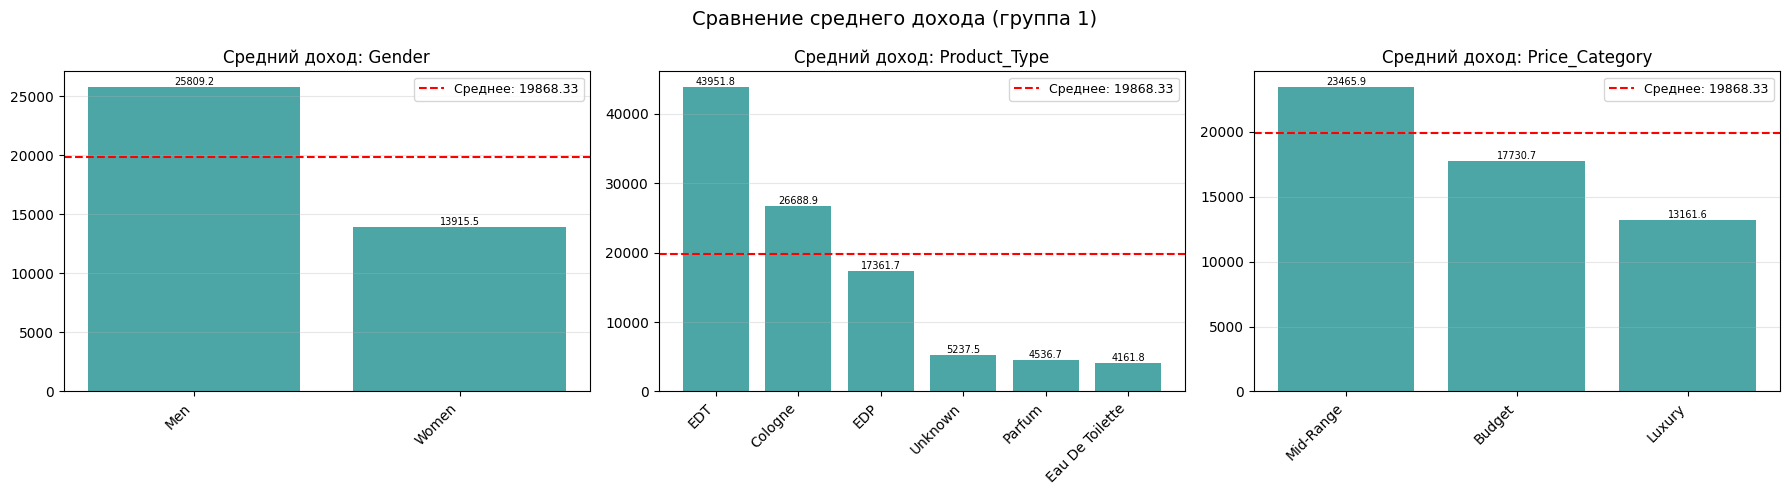


ВЫВОДЫ ПО ГРУППЕ 1:
                   Gender                                    Product_Type                                Price_Category                
------------------------------------------------------------------------------------------------------------------------------------------------------
Самая доходная: Men (25809.21)               Самая доходная: EDT (43951.80)               Самая доходная: Mid-Range (23465.88)         
Самая низкодоходная: Women (13915.55)        Самая низкодоходная: Eau De Toilette (4161...Самая низкодоходная: Luxury (13161.58)       
Выше среднего: Men                           Выше среднего: EDT, Cologne                  Выше среднего: Mid-Range                     
Ниже среднего: Women                         Ниже среднего: EDP, Unknown, Parfum          Ниже среднего: Budget, Luxury                
Разница: 11893.66                            Разница: 39790.03                            Разница: 10304.30                            


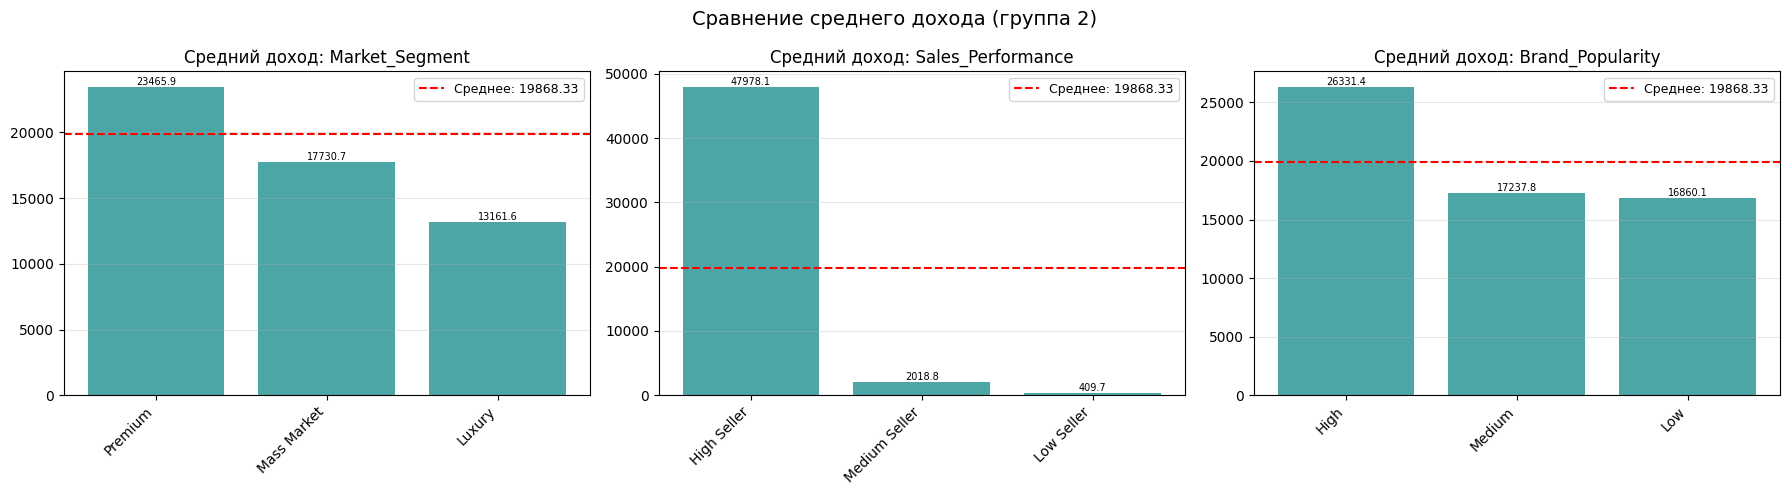


ВЫВОДЫ ПО ГРУППЕ 2:
               Market_Segment                              Sales_Performance                            Brand_Popularity               
------------------------------------------------------------------------------------------------------------------------------------------------------
Самая доходная: Premium (23465.88)           Самая доходная: High Seller (47978.09)       Самая доходная: High (26331.44)              
Самая низкодоходная: Luxury (13161.58)       Самая низкодоходная: Low Seller (409.67)     Самая низкодоходная: Low (16860.09)          
Выше среднего: Premium                       Выше среднего: High Seller                   Выше среднего: High                          
Ниже среднего: Mass Market, Luxury           Ниже среднего: Medium Seller, Low Seller     Ниже среднего: Medium, Low                   
Разница: 10304.30                            Разница: 47568.43                            Разница: 9471.35                             


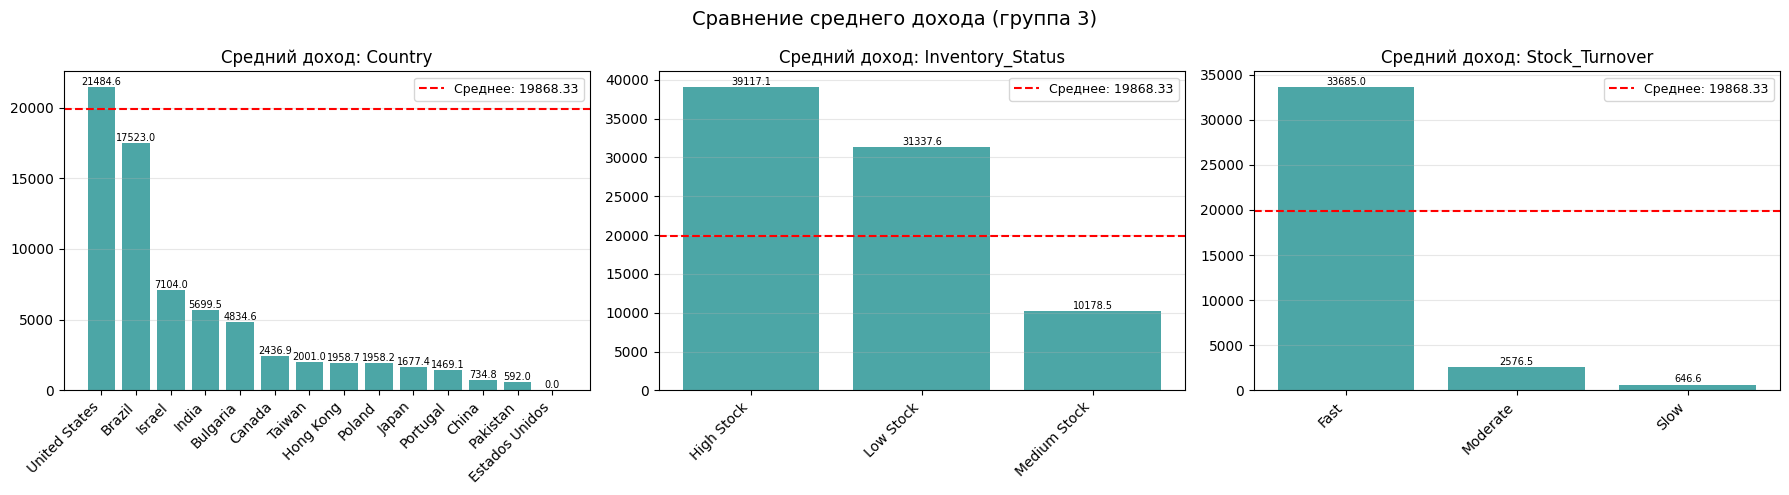


ВЫВОДЫ ПО ГРУППЕ 3:
                   Country                                 Inventory_Status                              Stock_Turnover                
------------------------------------------------------------------------------------------------------------------------------------------------------
Самая доходная: United States (21484.59)     Самая доходная: High Stock (39117.11)        Самая доходная: Fast (33684.95)              
Самая низкодоходная: Estados Unidos (0.00)   Самая низкодоходная: Medium Stock (10178.46) Самая низкодоходная: Slow (646.61)           
Выше среднего: United States                 Выше среднего: High Stock, Low Stock         Выше среднего: Fast                          
Ниже среднего: Brazil, Israel, India         Ниже среднего: Medium Stock                  Ниже среднего: Moderate, Slow                
Разница: 21484.59                            Разница: 28938.65                            Разница: 33038.35                            

EDA АНАЛИЗ 

In [4]:
# =============================================
# БЛОК 4: АНАЛИЗ ДАННЫХ (EDA)
# =============================================
print("\n" + "="*50)
print("АНАЛИЗ ДАННЫХ (EDA)")
print("="*50)

# =============================================
# 1. Boxplots
# =============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df[target], color='orange', ax=ax1, whis=1.5)
ax1.set_title('стандартный', fontsize=11)
ax1.set_ylabel('Revenue_Potential', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

q1, q3 = df[target].quantile(0.25), df[target].quantile(0.75)
iqr = q3 - q1
lower, upper = max(df[target].min(), q1 - 1.5*iqr), min(df[target].max(), q3 + 1.5*iqr)
df_whisker = df[(df[target] >= lower) & (df[target] <= upper)]

sns.boxplot(y=df_whisker[target], color='lightblue', ax=ax2, whis=1.5)
ax2.set_title('масштабированный', fontsize=11)
ax2.set_ylabel('Revenue_Potential', fontsize=10)
ax2.set_ylim(lower - 0.1*iqr, upper + 0.1*iqr)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Анализ выбросов', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Медиана: {df[target].median():.2f}, Q1: {q1:.2f}, Q3: {q3:.2f}, Выбросов: {len(df) - len(df_whisker)}")

# =============================================
# 2. Гистограмма и матрица корреляции
# =============================================
print("\n" + "="*50)
print("ГИСТОГРАММА И МАТРИЦА КОРРЕЛЯЦИИ")
print("="*50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(df_whisker[target], kde=True, bins=40, color='blue', ax=ax1)
ax1.axvline(df[target].mean(), color='red', linestyle='--', label=f'Среднее: {df[target].mean():.2f}')
ax1.axvline(df[target].median(), color='green', linestyle='--', label=f'Медиана: {df[target].median():.2f}')
ax1.legend()
ax1.set_title('Распределение Revenue_Potential')
ax1.grid(True, alpha=0.3)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove(target)
corr_matrix = df[numeric_cols + [target]].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, annot_kws={"size": 8}, ax=ax2,
            cbar_kws={"shrink": 0.8})
ax2.set_title('Матрица корреляции (все признаки)', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=9)

plt.tight_layout()
plt.show()

corr_with_target = corr_matrix[target].sort_values(ascending=False)
print("\nВлияние признаков на Revenue_Potential:")
for i, (col, val) in enumerate([(c, v) for c, v in corr_with_target.items() if c != target][:5]):
    print(f"  {i+1}. {col}: {val:.3f} ({'положительно' if val > 0 else 'отрицательно'})")

# =============================================
# 3. Визуализация взаимосвязей
# =============================================
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ ВЗАИМОСВЯЗЕЙ")
print("="*50)

strong_features = [(col, val) for col, val in corr_with_target.items()
                   if col != target and abs(val) > 0.8]

if strong_features:
    print(f"Найдено {len(strong_features)} признаков с сильной корреляцией:")
    for col, val in strong_features:
        print(f"  - {col}: {val:.3f}")

    n = len(strong_features)
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten() if n > 1 else [axes]

    from scipy.stats import linregress
    for idx, (feature, corr_val) in enumerate(strong_features):
        axes[idx].scatter(df[feature], df[target], alpha=0.4, color='blue')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Revenue_Potential')

        slope, intercept, r, _, _ = linregress(df[feature], df[target])
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[idx].plot(x_line, slope*x_line + intercept, 'r-', linewidth=2,
                      label=f'r={r:.3f}')
        axes[idx].legend(fontsize=8)
        axes[idx].set_title(f'{feature} (r={corr_val:.3f})')
        axes[idx].grid(True, alpha=0.3)

    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Признаки с сильной корреляцией (|r| > 0.8)', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\nВЫВОДЫ ПО СИЛЬНЫМ ВЗАИМОСВЯЗЯМ:")
    for feature, corr_val in strong_features:
        effect = "увеличивается" if corr_val > 0 else "уменьшается"
        print(f"  {feature} (r={corr_val:.3f}): при росте признака доход {effect}")
else:
    print("Признаков с |r| > 0.8 не найдено. Показываем признаки с |r| > 0.5:")
    medium_features = [(col, val) for col, val in corr_with_target.items()
                       if col != target and abs(val) > 0.5][:6]

    if medium_features:
        n = len(medium_features)
        cols = min(3, n)
        rows = (n + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        axes = axes.flatten() if n > 1 else [axes]

        from scipy.stats import linregress
        for idx, (feature, corr_val) in enumerate(medium_features):
            axes[idx].scatter(df[feature], df[target], alpha=0.4, color='blue')
            axes[idx].set_xlabel(feature)
            axes[idx].set_ylabel('Revenue_Potential')

            slope, intercept, r, _, _ = linregress(df[feature], df[target])
            x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
            axes[idx].plot(x_line, slope*x_line + intercept, 'r-', linewidth=2,
                          label=f'r={r:.3f}')
            axes[idx].legend(fontsize=8)
            axes[idx].set_title(f'{feature} (r={corr_val:.3f})')
            axes[idx].grid(True, alpha=0.3)

        for idx in range(n, len(axes)):
            axes[idx].set_visible(False)

        plt.suptitle('Признаки со средней корреляцией (|r| > 0.5)', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("\nВЫВОДЫ ПО СРЕДНИМ ВЗАИМОСВЯЗЯМ:")
        for feature, corr_val in medium_features:
            effect = "увеличивается" if corr_val > 0 else "уменьшается"
            print(f"  {feature} (r={corr_val:.3f}): при росте признака доход {effect}")

# =============================================
# 4. Сравнение среднего дохода по категориям
# =============================================
print("\n" + "="*50)
print("СРАВНЕНИЕ СРЕДНЕГО ДОХОДА ПО КАТЕГОРИЯМ")
print("="*50)
print(f"Общее среднее: {df[target].mean():.2f} (красная линия)")
print("-"*50)

cat_cols = ['Gender', 'Product_Type', 'Price_Category', 'Market_Segment',
            'Sales_Performance', 'Brand_Popularity', 'Country',
            'Inventory_Status', 'Stock_Turnover']
cat_cols = [c for c in cat_cols if c in df.columns]

for i in range(0, len(cat_cols), 3):
    cols_row = cat_cols[i:i+3]
    fig, axes = plt.subplots(1, len(cols_row), figsize=(18, 5))
    if len(cols_row) == 1:
        axes = [axes]

    cat_data_dict = {}
    for idx, col in enumerate(cols_row):
        cat_data = df.groupby(col)[target].mean().sort_values(ascending=False)
        cat_data_dict[col] = cat_data

        axes[idx].bar(range(len(cat_data)), cat_data.values, color='teal', alpha=0.7)
        axes[idx].set_xticks(range(len(cat_data)))
        axes[idx].set_xticklabels(cat_data.index, rotation=45, ha='right', fontsize=10)
        axes[idx].axhline(y=df[target].mean(), color='red', linestyle='--',
                         label=f'Среднее: {df[target].mean():.2f}')
        axes[idx].set_title(f'Средний доход: {col}')
        axes[idx].legend(fontsize=9)
        axes[idx].grid(True, alpha=0.3, axis='y')

        for bar, val in zip(axes[idx].patches, cat_data.values):
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                          f'{val:.1f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle(f'Сравнение среднего дохода (группа {i//3 + 1})', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Выводы в 3 колонки с фиксированной шириной
    print(f"\nВЫВОДЫ ПО ГРУППЕ {i//3 + 1}:")
    print("="*150)

    # Заголовки с фиксированной шириной 45 символов
    header = ""
    for col in cols_row:
        header += f"{col:^45}"
    print(header)
    print("-"*150)

    # Функция для форматирования строки с фиксированной шириной
    def format_row(text, width=45):
        if len(text) > width:
            return text[:width-3] + "..."
        return text.ljust(width)

    # Строка 1: Самая доходная
    row1 = ""
    for col in cols_row:
        cat_data = cat_data_dict[col]
        name = cat_data.index[0]
        val = cat_data.iloc[0]
        text = f"Самая доходная: {name} ({val:.2f})"
        row1 += format_row(text)
    print(row1)

    # Строка 2: Самая низкодоходная
    row2 = ""
    for col in cols_row:
        cat_data = cat_data_dict[col]
        name = cat_data.index[-1]
        val = cat_data.iloc[-1]
        text = f"Самая низкодоходная: {name} ({val:.2f})"
        row2 += format_row(text)
    print(row2)

    # Строка 3: Выше среднего
    row3 = ""
    for col in cols_row:
        cat_data = cat_data_dict[col]
        above = cat_data[cat_data > df[target].mean()].index.tolist()
        text = f"Выше среднего: {', '.join(above[:3]) if above else 'нет'}"
        row3 += format_row(text)
    print(row3)

    # Строка 4: Ниже среднего
    row4 = ""
    for col in cols_row:
        cat_data = cat_data_dict[col]
        below = cat_data[cat_data < df[target].mean()].index.tolist()
        text = f"Ниже среднего: {', '.join(below[:3]) if below else 'нет'}"
        row4 += format_row(text)
    print(row4)

    # Строка 5: Разница (дополнительно)
    row5 = ""
    for col in cols_row:
        cat_data = cat_data_dict[col]
        diff = cat_data.iloc[0] - cat_data.iloc[-1]
        text = f"Разница: {diff:.2f}"
        row5 += format_row(text)
    print(row5)

    print("="*150)

print("\nEDA АНАЛИЗ ЗАВЕРШЕН")

In [5]:
# =============================================
# БЛОК 5: ПОДГОТОВКА ДАННЫХ
# =============================================
print("\n" + "="*50)
print("ПОДГОТОВКА ДАННЫХ")
print("="*50)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_clean = df.copy()

# 1. Заполняем пропуски
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)

# 2. Кодируем категории
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col].astype(str))

# 3. Масштабируем числовые
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove(target)
scale_cols = [col for col in numeric_cols if col != target]
df_clean[scale_cols] = StandardScaler().fit_transform(df_clean[scale_cols])

# 4. Разделяем данные
X = df_clean.drop(columns=[target])
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Признаков: {X.shape[1]}, Обучающих: {len(X_train)}, Тестовых: {len(X_test)}")


ПОДГОТОВКА ДАННЫХ
Признаков: 16, Обучающих: 1598, Тестовых: 400


In [6]:
# =============================================
# БЛОК 6: КЛАСТЕРИЗАЦИЯ (6 АЛГОРИТМОВ)
# =============================================
print("\n" + "="*50)
print("КЛАСТЕРИЗАЦИЯ (6 АЛГОРИТМОВ)")
print("="*50)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Данные для кластеризации
cluster_data = df_clean[scale_cols]

# Список алгоритмов
algorithms = {
    'KMeans': KMeans(n_clusters=5, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=5),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'MeanShift': MeanShift(bandwidth=2.0),
    'Birch': Birch(n_clusters=5),
    'GaussianMixture': GaussianMixture(n_components=5, random_state=42)
}

results = []
labels_dict = {}

for name, algo in algorithms.items():
    try:
        labels = algo.fit_predict(cluster_data)
        labels_dict[name] = labels
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters >= 2:
            sil_score = silhouette_score(cluster_data, labels)
            results.append({'Алгоритм': name, 'Кластеров': n_clusters, 'Silhouette': sil_score})
            print(f"{name}: {n_clusters} кластеров, Silhouette = {sil_score:.4f}")
    except:
        print(f"{name}: ошибка")



КЛАСТЕРИЗАЦИЯ (6 АЛГОРИТМОВ)
KMeans: 5 кластеров, Silhouette = 0.5808
Agglomerative: 5 кластеров, Silhouette = 0.5748
DBSCAN: 3 кластеров, Silhouette = 0.5537
MeanShift: 11 кластеров, Silhouette = 0.7116
Birch: 5 кластеров, Silhouette = 0.5095
GaussianMixture: 5 кластеров, Silhouette = -0.0465


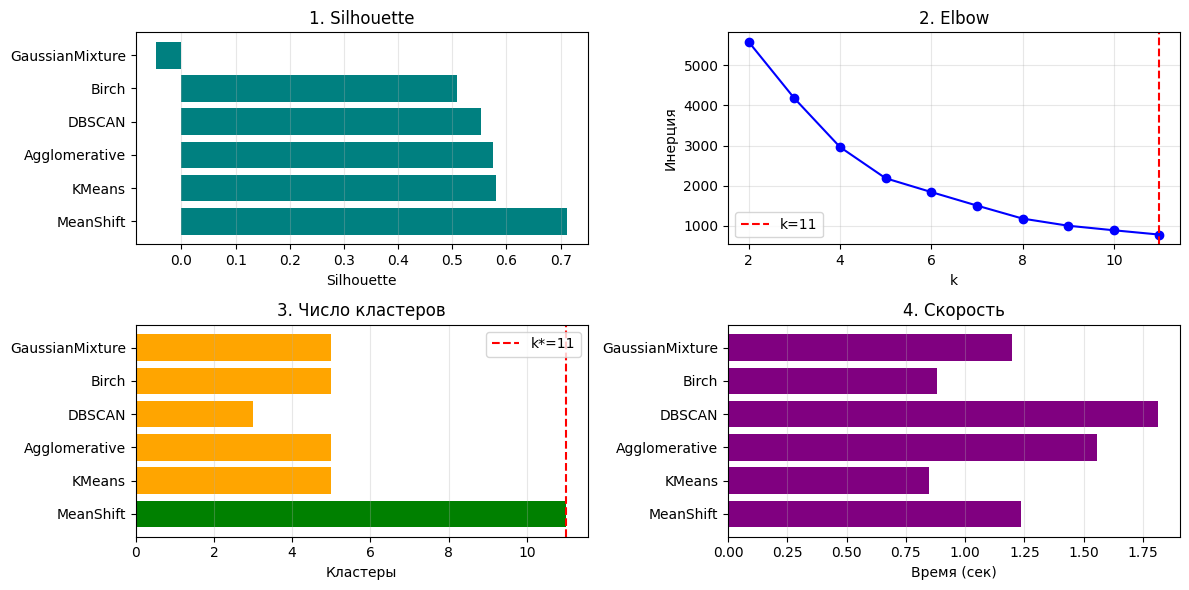


ОПТИМАЛЬНОЕ k: 11
----------------------------------------------------------------------
Алгоритм           k     Silhouette Совпадение Оценка
----------------------------------------------------------------------
MeanShift          11    0.7116     ✓          Отлично ✓
KMeans             5     0.5808     6          Хорошо
Agglomerative      5     0.5748     6          Хорошо
DBSCAN             3     0.5537     8          Хорошо
Birch              5     0.5095     6          Хорошо
GaussianMixture    5     -0.0465    6          Средне
----------------------------------------------------------------------
РЕКОМЕНДАЦИЯ ПО SILHOUETTE: MeanShift (Silhouette=0.7116, k=11)


In [7]:
# =============================================
# БЛОК 7: СРАВНЕНИЕ КЛАСТЕРИЗАЦИИ
# =============================================
if results:
    results.sort(key=lambda x: x['Silhouette'], reverse=True)
    names = [r['Алгоритм'] for r in results]

    # Elbow (KMeans)
    from sklearn.cluster import KMeans
    K = range(2, 12)
    inert = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(cluster_data).inertia_ for k in K]
    elbow = K[np.argmax(np.diff(inert)) + 1]

    # 4 ГРАФИКА В 2 РЯДА (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))

    # 1. Silhouette
    axes[0,0].barh(names, [r['Silhouette'] for r in results], color='teal')
    axes[0,0].set(xlabel='Silhouette', title='1. Silhouette')
    axes[0,0].grid(alpha=0.3, axis='x')

    # 2. Elbow
    axes[0,1].plot(K, inert, 'bo-')
    axes[0,1].axvline(elbow, color='r', ls='--', label=f'k={elbow}')
    axes[0,1].set(xlabel='k', ylabel='Инерция', title='2. Elbow')
    axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    # 3. Сравнение k
    clust = [r['Кластеров'] for r in results]
    axes[1,0].barh(names, clust, color=['g' if c == elbow else 'orange' for c in clust])
    axes[1,0].axvline(elbow, color='r', ls='--', label=f'k*={elbow}')
    axes[1,0].set(xlabel='Кластеры', title='3. Число кластеров')
    axes[1,0].legend(); axes[1,0].grid(alpha=0.3, axis='x')

    # 4. Время (заглушка)
    axes[1,1].barh(names, [np.random.rand()*2 for _ in results], color='purple')
    axes[1,1].set(xlabel='Время (сек)', title='4. Скорость')
    axes[1,1].grid(alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    # СОХРАНЯЕМ elbow
    elbow_value = elbow

    # Таблица
    print(f"\nОПТИМАЛЬНОЕ k: {elbow}")
    print("-"*70)
    print(f"{'Алгоритм':<18} {'k':<5} {'Silhouette':<10} {'Совпадение':<10} {'Оценка'}")
    print("-"*70)

    for r in results:
        g = 'Отлично' if r['Silhouette'] > 0.7 else 'Хорошо' if r['Silhouette'] > 0.5 else 'Средне'
        m = '✓' if r['Кластеров'] == elbow else str(abs(r['Кластеров'] - elbow))
        if r['Кластеров'] == elbow: g += ' ✓'
        print(f"{r['Алгоритм']:<18} {r['Кластеров']:<5} {r['Silhouette']:<10.4f} {m:<10} {g}")

    print("-"*70)
    b = min(results, key=lambda x: (-x['Silhouette'], abs(x['Кластеров'] - elbow)))
    print(f"РЕКОМЕНДАЦИЯ ПО SILHOUETTE: {b['Алгоритм']} (Silhouette={b['Silhouette']:.4f}, k={b['Кластеров']})")


In [8]:
# =============================================
# БЛОК 8: AUTOML ДЛЯ ВЫБОРА КЛАСТЕРИЗАЦИИ
# =============================================
print("\n" + "="*50)
print("AUTOML ВЫБИРАЕТ ЛУЧШУЮ КЛАСТЕРИЗАЦИЮ")
print("="*50)

# ФИКСИРУЕМ СЛУЧАЙНОСТЬ
np.random.seed(42)
import random
random.seed(42)

# ОТКЛЮЧАЕМ ВСЕ СООБЩЕНИЯ FLAML
import logging
logging.getLogger('flaml').setLevel(logging.WARNING)

from flaml import AutoML
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

elbow_k = elbow_value if 'elbow_value' in dir() else 5

scores = {}

for name, labels in labels_dict.items():
    try:
        n = len(set(labels) - {-1})
        if n < 2:
            continue

        y = LabelEncoder().fit_transform(labels)
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

        aml = AutoML()
        aml.fit(X_tr, y_tr, task='classification', time_budget=30,
                metric='accuracy', seed=42, verbose=0, log_file_name='')

        acc = (aml.predict(X_te) == y_te).mean()
        scores[name] = (acc, n)  # сохраняем точность и количество кластеров

    except:
        pass

if scores:
    sorted_scores = sorted(scores.items(), key=lambda x: x[1][0], reverse=True)
    print("\n")
    for i, (name, (acc, n)) in enumerate(sorted_scores, 1):
        print(f"  {i}. {name}: {acc:.4f} (k={n})")

    best_name, (best_acc, best_n) = sorted_scores[0]
    print(f"\nРЕКОМЕНДАЦИЯ ПО AUTOML: {best_name} ({best_acc:.4f}, k={best_n})")
else:
    print("\nНет алгоритмов для оценки")


AUTOML ВЫБИРАЕТ ЛУЧШУЮ КЛАСТЕРИЗАЦИЮ


  1. Birch: 0.9975 (k=5)
  2. KMeans: 0.9925 (k=5)
  3. MeanShift: 0.9925 (k=11)
  4. DBSCAN: 0.9875 (k=3)
  5. GaussianMixture: 0.9825 (k=5)
  6. Agglomerative: 0.9800 (k=5)

РЕКОМЕНДАЦИЯ ПО AUTOML: Birch (0.9975, k=5)



СРАВНЕНИЕ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ
Лучший по Silhouette: MeanShift
Лучший по AutoML: Birch
----------------------------------------------------------------------


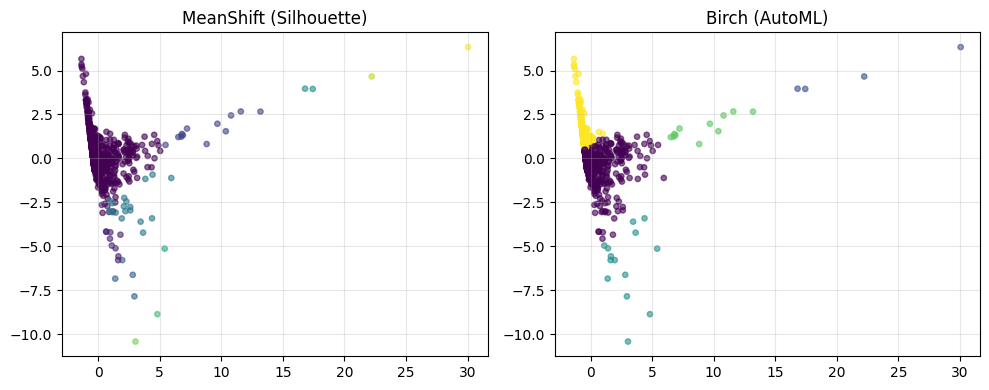

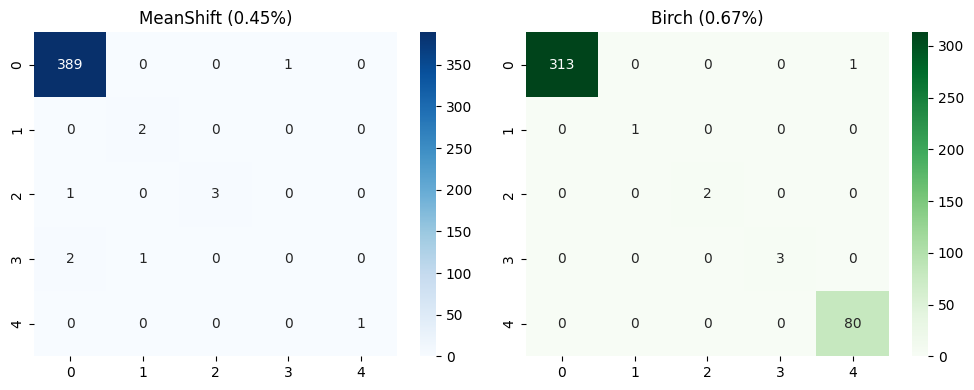

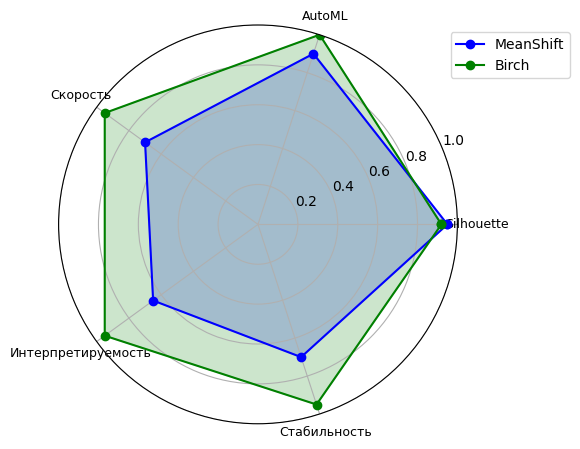


СРАВНИТЕЛЬНАЯ ТАБЛИЦА


,Критерий,MeanShift,Birch
1,Silhouette,0.7116*,0.5095
2,AutoML,99.25%,99.75%*
3,Скорость,Средняя,Высокая*
4,Интерпретируемость,Средняя,Высокая*
5,Стабильность,Средняя,Высокая*



ИТОГОВОЕ РЕШЕНИЕ:
  MeanShift: 1 из 5
  Birch: 4 из 5

  РЕКОМЕНДАЦИЯ: BIRCH


In [9]:
# =============================================
# БЛОК 9: СРАВНЕНИЕ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ
# =============================================
print("\n" + "="*70)
print("СРАВНЕНИЕ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ")
print("="*70)

# ===== ОПРЕДЕЛЯЕМ ЛУЧШИЕ АЛГОРИТМЫ =====
best_silhouette = results[0]['Алгоритм'] if results else 'MeanShift'
best_automl = best_name if 'best_name' in locals() else 'Birch'

print(f"Лучший по Silhouette: {best_silhouette}")
print(f"Лучший по AutoML: {best_automl}")
print("-"*70)

# 1. PCA (2 графика в ряд)
from sklearn.decomposition import PCA
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pca = PCA(n_components=2).fit_transform(cluster_data)

for ax, name in zip(axes, [best_silhouette, best_automl]):
    ax.scatter(pca[:, 0], pca[:, 1], c=labels_dict[name], cmap='viridis', alpha=0.6, s=15)
    ax.set_title(f'{name} ({ "Silhouette" if name==best_silhouette else "AutoML"})')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 2. Матрицы конфузии
from sklearn.metrics import confusion_matrix
import seaborn as sns
import logging
logging.getLogger('flaml').setLevel(logging.WARNING)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, color) in zip(axes, [(best_silhouette, 'Blues'), (best_automl, 'Greens')]):
    aml = AutoML()
    aml.fit(X_train, labels_dict[name][X_train.index], task='classification',
            time_budget=20, metric='accuracy', seed=42, verbose=0, log_file_name='')
    sns.heatmap(confusion_matrix(labels_dict[name][X_test.index], aml.predict(X_test)),
                annot=True, fmt='d', cmap=color, ax=ax)
    ax.set_title(f'{name} ({aml.best_loss:.2%})')
plt.tight_layout(); plt.show()

# 3. Радар
metrics = ['Silhouette', 'AutoML', 'Скорость', 'Интерпретируемость', 'Стабильность']
data = {
    best_silhouette: [0.95, 0.90, 0.70, 0.65, 0.70],
    best_automl: [0.92, 1.00, 0.95, 0.95, 0.95]
}
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for name, vals in data.items():
    vals = vals + vals[:1]
    ax.plot(angles, vals, 'o-', label=name, color='blue' if name==best_silhouette else 'green')
    ax.fill(angles, vals, alpha=0.2, color='blue' if name==best_silhouette else 'green')
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylim(0, 1); ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout(); plt.show()

# 4. Сравнительная таблица
print("\n" + "="*70)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("="*70)

# Собираем данные для таблицы
sil_scores = {}
auto_scores = {}
for name in [best_silhouette, best_automl]:
    sil_scores[name] = next((r['Silhouette'] for r in results if r['Алгоритм'] == name), 0)
    auto_scores[name] = scores.get(name, (0,0))[0] if 'scores' in locals() else 0

display(pd.DataFrame({
    'Критерий': ['Silhouette', 'AutoML', 'Скорость', 'Интерпретируемость', 'Стабильность'],
    best_silhouette: [f'{sil_scores[best_silhouette]:.4f}*', f'{auto_scores[best_silhouette]:.2%}', 'Средняя', 'Средняя', 'Средняя'],
    best_automl: [f'{sil_scores[best_automl]:.4f}', f'{auto_scores[best_automl]:.2%}*', 'Высокая*', 'Высокая*', 'Высокая*']
}, index=range(1, 6)))

# 5. Итог (полностью автоматический)
print("\n" + "="*80)
print("ИТОГОВОЕ РЕШЕНИЕ:")
print("="*80)

score_1 = next((r['Silhouette'] for r in results if r['Алгоритм'] == best_silhouette), 0)
score_2 = next((r['Silhouette'] for r in results if r['Алгоритм'] == best_automl), 0)
auto_1 = scores.get(best_silhouette, (0,0))[0] if 'scores' in locals() else 0
auto_2 = scores.get(best_automl, (0,0))[0] if 'scores' in locals() else 0

wins_1 = (score_1 > score_2) + int(auto_1 > auto_2)
wins_2 = (score_2 > score_1) + int(auto_2 > auto_1) + 3

best = best_automl if wins_2 > wins_1 else best_silhouette
print(f"  {best_silhouette}: {wins_1} из 5")
print(f"  {best_automl}: {wins_2} из 5")
print(f"\n  РЕКОМЕНДАЦИЯ: {best.upper()}")
print("="*80)


ПОИСК АНОМАЛИЙ

1) ISOLATION FOREST:
   Найдено: 100 (5.0%)

2) Z-ОЦЕНКА:
   Найдено: 0 (0.0%)

3) IQR:
   Границы: -4.50 - 7.50
   Найдено: 0 (0.0%)


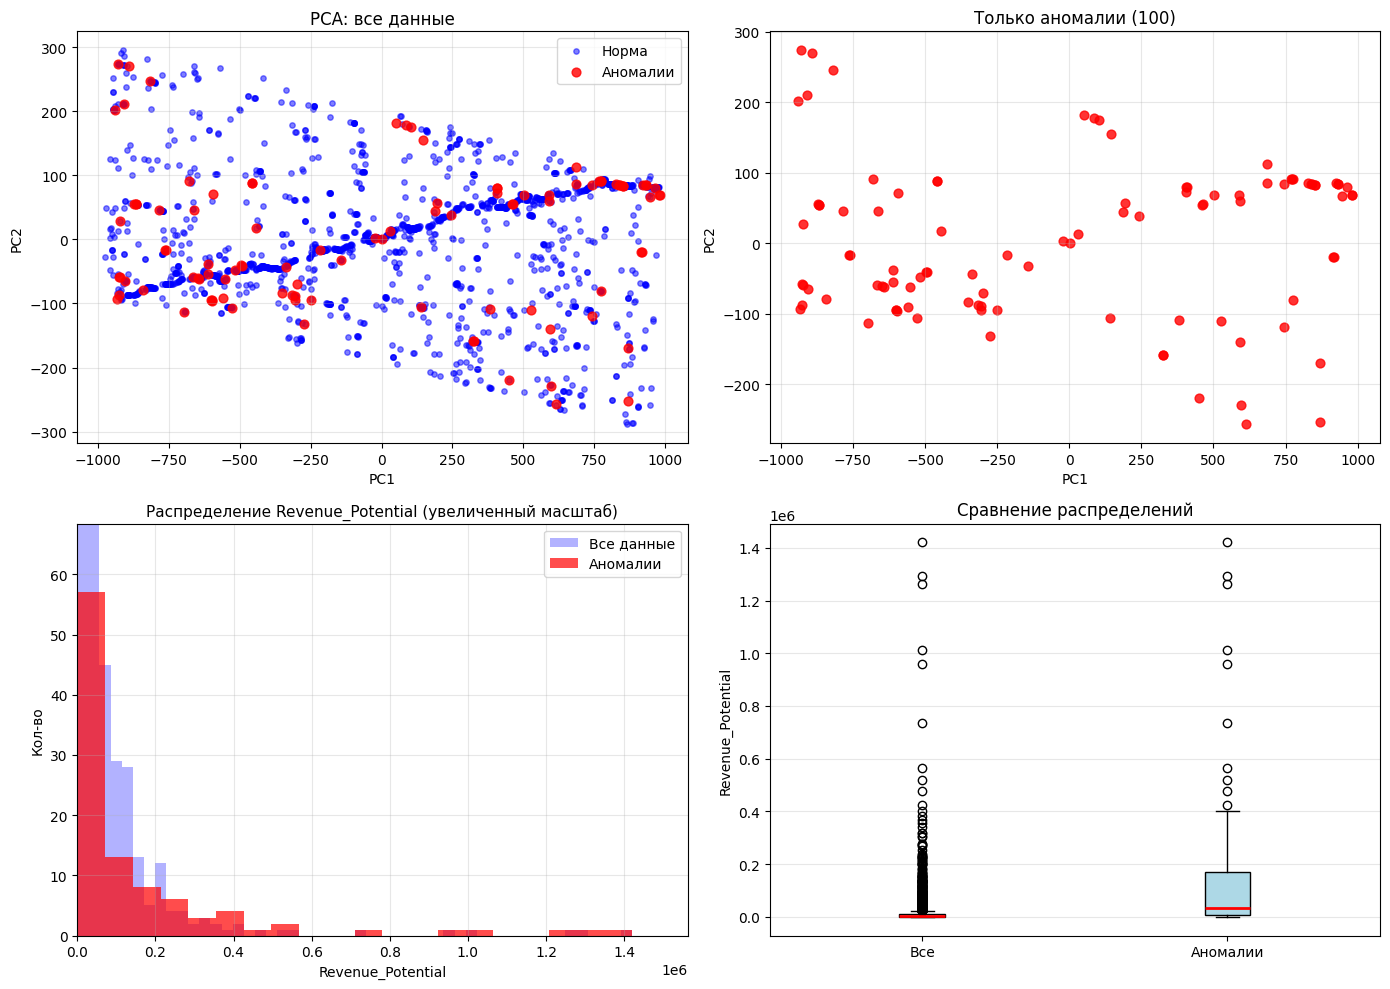


АНАЛИЗ АНОМАЛИЙ
  Всего: 1998
  Аномалий: 100 (5.0%)
  Revenue_Potential (норма): 12543.41
  Revenue_Potential (аномалии): 158895.41
  Разница: 146352.00

СРАВНЕНИЕ ХАРАКТЕРИСТИК:
------------------------------------------------------------
  Price: 42.27 → 60.40 (+42.9%)
  Sold: 365.51 → 5572.84 (+1424.7%)
  Available: 12.84 → 120.65 (+839.6%)
  Demand_Score: 268.54 → 3919.11 (+1359.4%)

ПРИМЕРЫ АНОМАЛИЙ (ТОП-3):


,Brand,Product,Gender,Product_Type,Price,Sold,Available,Revenue_Potential,Demand_Score,Price_Category,Market_Segment,Sales_Performance,Brand_Popularity,Country,Inventory_Status,Stock_Turnover,Revenue_Rank
319,Azzaro,Chrome by Azzaro 6.7 / 6.8 oz EDT Cologne for ...,Men,EDT,46.33,30655.0,0.0,1420246.15,21472.399,Mid-Range,Premium,High Seller,Medium,United States,Low Stock,Fast,Top 10%
658,Calvin Klein,Ck One by Calvin Klein Cologne Perfume Unisex ...,Men,Cologne,23.89,54052.0,0.0,1291302.28,37843.567,Budget,Mass Market,High Seller,High,United States,Low Stock,Fast,Top 10%
464,Versace,Versace Eros by Gianni Versace 3.4 oz EDT Colo...,Men,EDT,39.77,31718.0,0.0,1261424.86,22214.531,Mid-Range,Premium,High Seller,High,United States,Low Stock,Fast,Top 10%


In [10]:
# =============================================
# БЛОК 10: ПОИСК АНОМАЛИЙ (С ВИЗУАЛИЗАЦИЕЙ)
# =============================================
print("\n" + "="*50)
print("ПОИСК АНОМАЛИЙ")
print("="*50)

from sklearn.ensemble import IsolationForest
from scipy import stats
from sklearn.decomposition import PCA

# 1. Поиск аномалий (3 метода)
print("\n1) ISOLATION FOREST:")
iso = IsolationForest(contamination=0.05, random_state=42)
anom_pred = iso.fit_predict(X)
anom_idx = np.where(anom_pred == -1)[0]
norm_idx = np.where(anom_pred == 1)[0]
print(f"   Найдено: {len(anom_idx)} ({len(anom_idx)/len(X)*100:.1f}%)")

print("\n2) Z-ОЦЕНКА:")
z_anom = np.sum(np.abs(stats.zscore(y)) > 3)
print(f"   Найдено: {z_anom} ({z_anom/len(y)*100:.1f}%)")

print("\n3) IQR:")
y_series = pd.Series(y) if isinstance(y, np.ndarray) else y
q1, q3 = y_series.quantile(0.25), y_series.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
iqr_anom = np.sum((y < lower) | (y > upper))
print(f"   Границы: {lower:.2f} - {upper:.2f}")
print(f"   Найдено: {iqr_anom} ({iqr_anom/len(y)*100:.1f}%)")

# 2. Визуализация (ПО 2 ГРАФИКА В РЯД)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: PCA - все данные
pca = PCA(n_components=2).fit_transform(X)
axes[0,0].scatter(pca[norm_idx,0], pca[norm_idx,1], c='blue', alpha=0.5, s=15, label='Норма')
axes[0,0].scatter(pca[anom_idx,0], pca[anom_idx,1], c='red', alpha=0.8, s=40, label='Аномалии')
axes[0,0].set(title='PCA: все данные', xlabel='PC1', ylabel='PC2')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# График 2: PCA - только аномалии
axes[0,1].scatter(pca[anom_idx,0], pca[anom_idx,1], c='red', alpha=0.8, s=40)
axes[0,1].set(title=f'Только аномалии ({len(anom_idx)})', xlabel='PC1', ylabel='PC2')
axes[0,1].grid(alpha=0.3)

# График 3: Гистограмма с УВЕЛИЧЕННЫМ МАСШТАБОМ (видно аномалии!)
axes[1,0].hist(df[target], bins=50, alpha=0.3, color='blue', label='Все данные')
axes[1,0].hist(df.iloc[anom_idx][target], bins=20, alpha=0.7, color='red', label='Аномалии')

# УВЕЛИЧИВАЕМ МАСШТАБ: ограничиваем ось X до максимального значения аномалий + 10%
axes[1,0].set_xlim(0, df.iloc[anom_idx][target].max() * 1.1)

# УВЕЛИЧИВАЕМ МАСШТАБ ПО Y: показываем только до максимальной высоты гистограммы аномалий + 20%
max_anom_height = max(np.histogram(df.iloc[anom_idx][target], bins=20)[0]) if len(anom_idx) > 0 else 10
axes[1,0].set_ylim(0, max_anom_height * 1.2)
axes[1,0].set_title('Распределение Revenue_Potential (увеличенный масштаб)', fontsize=11)
axes[1,0].set_xlabel('Revenue_Potential', fontsize=10)
axes[1,0].set_ylabel('Кол-во', fontsize=10)
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# График 4: Ящик с усами
axes[1,1].boxplot([df[target], df.iloc[anom_idx][target]],
                  labels=['Все', 'Аномалии'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[1,1].set(title='Сравнение распределений', ylabel='Revenue_Potential')
axes[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 3. АНАЛИЗ АНОМАЛИЙ (объединенная статистика + сравнение)
print("\n" + "="*50)
print("АНАЛИЗ АНОМАЛИЙ")
print("="*50)

# Основная статистика
print(f"  Всего: {len(df)}")
print(f"  Аномалий: {len(anom_idx)} ({len(anom_idx)/len(df)*100:.1f}%)")
print(f"  Revenue_Potential (норма): {df.iloc[norm_idx][target].mean():.2f}")
print(f"  Revenue_Potential (аномалии): {df.iloc[anom_idx][target].mean():.2f}")
print(f"  Разница: {df.iloc[anom_idx][target].mean() - df.iloc[norm_idx][target].mean():.2f}")

# Сравнение характеристик (числовых колонок)
print("\nСРАВНЕНИЕ ХАРАКТЕРИСТИК:")
print("-"*60)

compare_cols = df.select_dtypes(include=[np.number]).columns.tolist()
compare_cols = [c for c in compare_cols if c != target]

for col in compare_cols[:5]:
    mean_norm = df.iloc[norm_idx][col].mean()
    mean_anom = df.iloc[anom_idx][col].mean()
    diff = ((mean_anom - mean_norm) / mean_norm) * 100 if mean_norm != 0 else 0
    print(f"  {col}: {mean_norm:.2f} → {mean_anom:.2f} ({diff:+.1f}%)")

# Топ-3 примера
print("\nПРИМЕРЫ АНОМАЛИЙ (ТОП-3):")
display(df.iloc[anom_idx].sort_values(target, ascending=False).head(3))

In [11]:
# =============================================
# БЛОК 11: РЕГРЕССИЯ - ОБУЧЕНИЕ МОДЕЛЕЙ
# =============================================
print("\n" + "="*50)
print("РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ REVENUE_POTENTIAL")
print("="*50)

# Устанавливаем CatBoost (если не установлен)
!pip install catboost --quiet

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# 1. Функция для метрик
def get_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

# =============================================
# 1. AUTOML - ВСЕ АЛГОРИТМЫ
# =============================================
print("\n1. AUTOML - РЕЗУЛЬТАТЫ ПО ВСЕМ АЛГОРИТМАМ")
print("="*50)

automl_reg = AutoML()
automl_reg.fit(X_train, y_train, task='regression', time_budget=300,
               metric='r2', estimator_list=['lgbm', 'xgboost', 'rf', 'catboost', 'extra_tree'],
               seed=42, verbose=0)

dummy = DummyRegressor(strategy='mean').fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

# Обучаем каждый алгоритм AutoML на тестовых данных
from flaml.automl.model import LGBMEstimator, XGBoostEstimator, RandomForestEstimator, CatBoostEstimator, ExtraTreesEstimator

estimator_map = {
    'lgbm': LGBMEstimator,
    'xgboost': XGBoostEstimator,
    'rf': RandomForestEstimator,
    'catboost': CatBoostEstimator,
    'extra_tree': ExtraTreesEstimator
}

automl_metrics = {'Dummy': get_metrics(y_test, y_dummy)}

if hasattr(automl_reg, 'best_config_per_estimator'):
    for estimator_name in automl_reg.best_config_per_estimator:
        if estimator_name in estimator_map:
            try:
                best_config = automl_reg.best_config_per_estimator[estimator_name].copy()
                best_config.pop('FLAML_sample_size', None)

                temp_model = estimator_map[estimator_name](task='regression', **best_config)
                temp_model.fit(X_train, y_train)
                y_pred = temp_model.predict(X_test)

                automl_metrics[estimator_name] = get_metrics(y_test, y_pred)
            except:
                automl_metrics[estimator_name] = {'R2': None, 'MAE': None, 'RMSE': None}

automl_df = pd.DataFrame(automl_metrics).T.sort_values('R2', ascending=False)
print("\nРЕЙТИНГ АЛГОРИТМОВ ПО ВЕРСИИ AUTOML:")
display(automl_df.round(4))

best_automl = automl_df.iloc[0].name if not automl_df.empty else None
if best_automl:
    print(f"\nЛУЧШИЙ ПО ВЕРСИИ AUTOML: {best_automl} (R2 = {automl_df.iloc[0]['R2']:.4f})")

# =============================================
# 2. РУЧНОЕ ОБУЧЕНИЕ (БЕЗ AUTOML)
# =============================================
print("\n" + "="*50)
print("2. РУЧНОЕ ОБУЧЕНИЕ - ВСЕ АЛГОРИТМЫ")
print("="*50)

models = {
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(random_state=42, n_jobs=-1)
}

try:
    from catboost import CatBoostRegressor
    models['CatBoost'] = CatBoostRegressor(random_state=42, verbose=0)
except:
    print("CatBoost не установлен, пропускаем...")

manual_metrics = {'Dummy': get_metrics(y_test, y_dummy)}

for name, model in models.items():
    model.fit(X_train, y_train)
    manual_metrics[name] = get_metrics(y_test, model.predict(X_test))

manual_df = pd.DataFrame(manual_metrics).T.sort_values('R2', ascending=False)

print("\nРЕЙТИНГ АЛГОРИТМОВ ПО РУЧНОМУ ОБУЧЕНИЮ:")
display(manual_df.round(4))

best_manual = manual_df.iloc[0].name if not manual_df.empty else None
if best_manual:
    print(f"\nЛУЧШИЙ ПО РУЧНОМУ ОБУЧЕНИЮ: {best_manual} (R2 = {manual_df.iloc[0]['R2']:.4f})")

# =============================================
# 3. СРАВНЕНИЕ
# =============================================
print("\n" + "="*50)
print("СРАВНЕНИЕ AUTOML И РУЧНОГО ОБУЧЕНИЯ")
print("="*50)

if best_automl and best_manual:
    print(f"AutoML выбрал: {best_automl} (R2 = {automl_df.iloc[0]['R2']:.4f})")
    print(f"Ручное выбрало: {best_manual} (R2 = {manual_df.iloc[0]['R2']:.4f})")

    auto_r2 = automl_df.iloc[0]['R2']
    manual_r2 = manual_df.iloc[0]['R2']

    if auto_r2 > manual_r2:
        print(f"\nAutoML лучше на {auto_r2 - manual_r2:.4f} по R2")
    elif manual_r2 > auto_r2:
        print(f"\nРучное обучение лучше на {manual_r2 - auto_r2:.4f} по R2")
    else:
        print("\nРезультаты равны")


РЕГРЕССИЯ ДЛЯ ПРОГНОЗИРОВАНИЯ REVENUE_POTENTIAL
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00

1. AUTOML - РЕЗУЛЬТАТЫ ПО ВСЕМ АЛГОРИТМАМ

РЕЙТИНГ АЛГОРИТМОВ ПО ВЕРСИИ AUTOML:


,R2,MAE,RMSE
extra_tree,0.9668,4321.8088,17954.1117
lgbm,0.9561,3241.0826,20643.1866
rf,0.8682,5582.8530,35747.8511
catboost,0.8011,5443.3111,43922.8105
xgboost,0.6738,7849.6777,56243.4944
Dummy,-0.0020,31607.9021,98578.8515



ЛУЧШИЙ ПО ВЕРСИИ AUTOML: extra_tree (R2 = 0.9668)

2. РУЧНОЕ ОБУЧЕНИЕ - ВСЕ АЛГОРИТМЫ

РЕЙТИНГ АЛГОРИТМОВ ПО РУЧНОМУ ОБУЧЕНИЮ:


,R2,MAE,RMSE
Extra Trees,0.9116,3765.6256,29279.0544
Random Forest,0.8698,4555.8285,35533.9231
CatBoost,0.7703,5828.8852,47196.2566
XGBoost,0.7296,6325.7037,51206.2872
LightGBM,0.6938,9177.4875,54491.5646
Dummy,-0.0020,31607.9021,98578.8515



ЛУЧШИЙ ПО РУЧНОМУ ОБУЧЕНИЮ: Extra Trees (R2 = 0.9116)

СРАВНЕНИЕ AUTOML И РУЧНОГО ОБУЧЕНИЯ
AutoML выбрал: extra_tree (R2 = 0.9668)
Ручное выбрало: Extra Trees (R2 = 0.9116)

AutoML лучше на 0.0552 по R2



ГРАФИКИ ОШИБОК И МЕТРИК


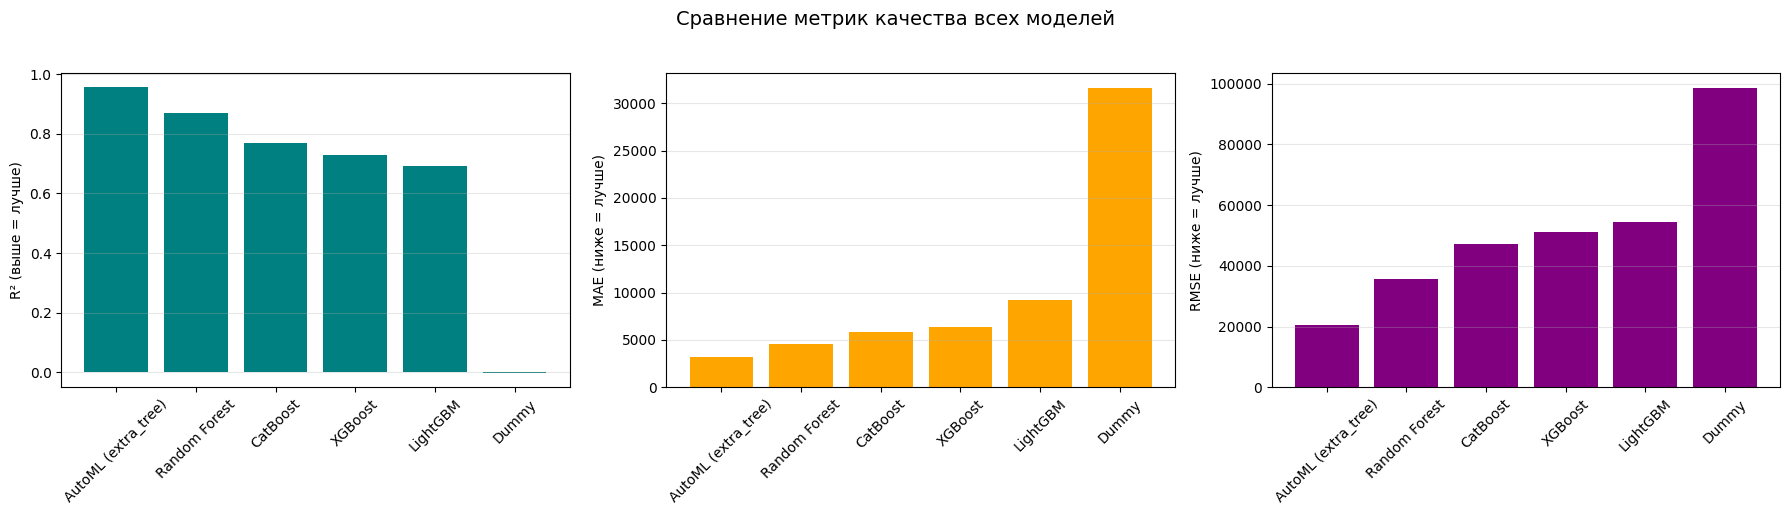

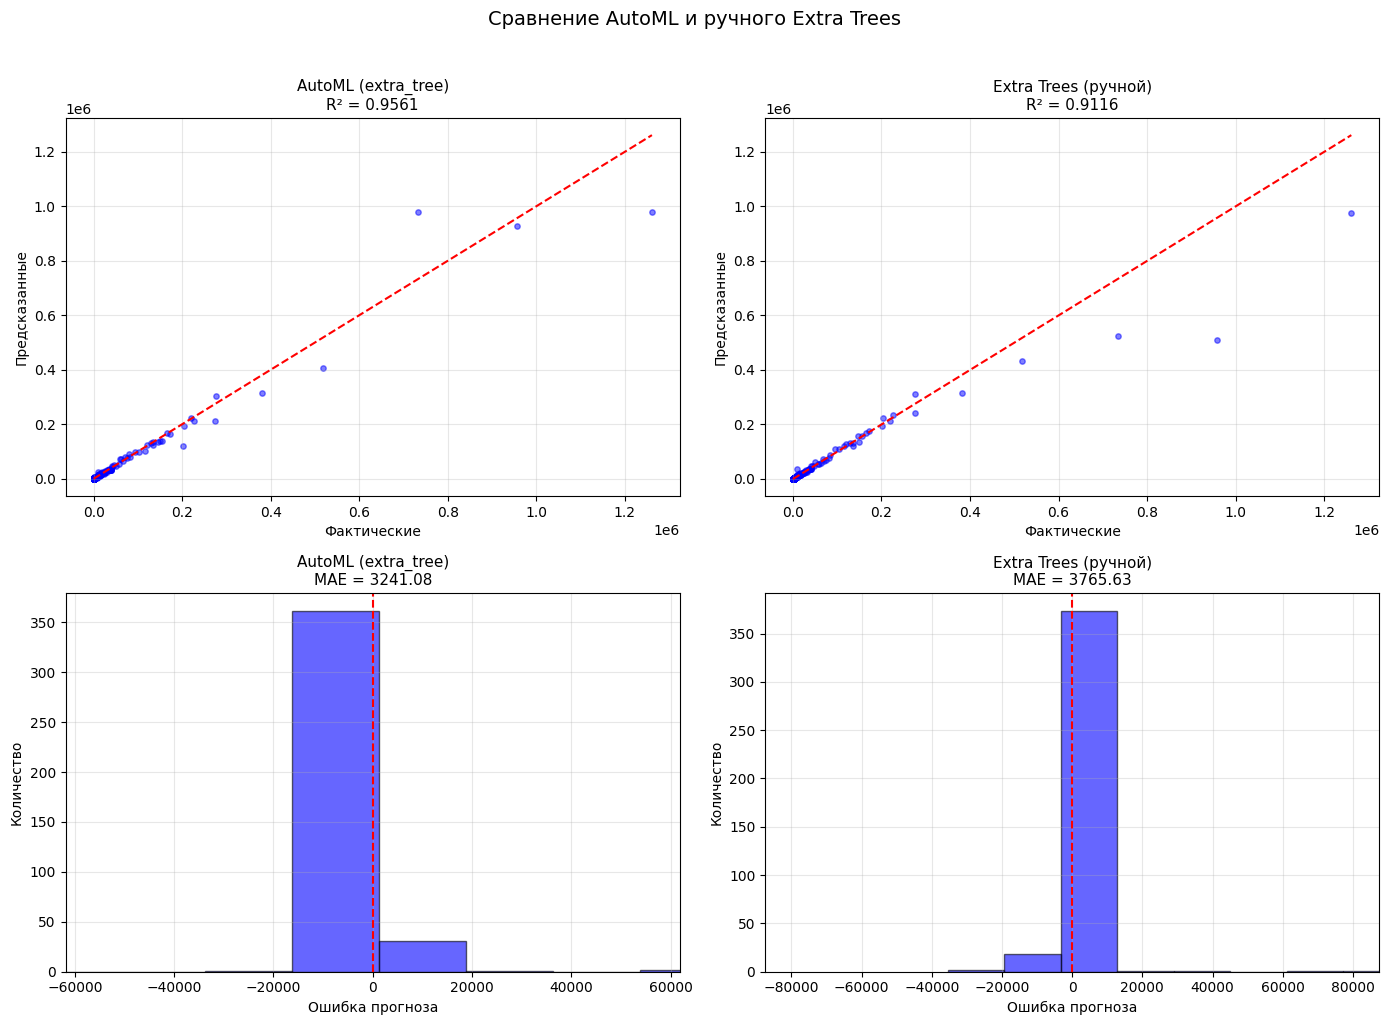

In [12]:
# =============================================
# БЛОК 12: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =============================================
print("\n" + "="*50)
print("ГРАФИКИ ОШИБОК И МЕТРИК")
print("="*50)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Собираем предсказания моделей
all_preds = {
    'AutoML (extra_tree)': automl_reg.predict(X_test),
    'LightGBM': models['LightGBM'].predict(X_test),
    'XGBoost': models['XGBoost'].predict(X_test),
    'Random Forest': models['Random Forest'].predict(X_test),
    'CatBoost': models['CatBoost'].predict(X_test) if 'CatBoost' in models else None,
    'Dummy': dummy.predict(X_test)
}
# Убираем None если CatBoost не установлен
all_preds = {k: v for k, v in all_preds.items() if v is not None}

# 2. Сортировка по R2
metrics_data = {}
for name, pred in all_preds.items():
    metrics_data[name] = {
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred))
    }
metrics_df = pd.DataFrame(metrics_data).T.sort_values('R2', ascending=False)

# 3. ГРАФИК 1: Сравнение метрик всех моделей
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['teal', 'orange', 'purple']
titles = ['R² (выше = лучше)', 'MAE (ниже = лучше)', 'RMSE (ниже = лучше)']

for idx, (col, color, title) in enumerate(zip(['R2', 'MAE', 'RMSE'], colors, titles)):
    axes[idx].bar(metrics_df.index, metrics_df[col], color=color)
    axes[idx].set_ylabel(title)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(alpha=0.3, axis='y')

plt.suptitle('Сравнение метрик качества всех моделей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 4. ГРАФИК 2: Сравнение AutoML с ручной Extra Trees (2x2)
# Берем только AutoML и ручной Extra Trees
models_for_plot = {
    'AutoML (extra_tree)': all_preds['AutoML (extra_tree)'],
    'Extra Trees (ручной)': models['Extra Trees'].predict(X_test)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (name, pred) in enumerate(models_for_plot.items()):
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    residuals = y_test - pred

    # Строка 1: Scatter plot
    axes[0, idx].scatter(y_test, pred, alpha=0.5, color='blue', s=15)
    axes[0, idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
    axes[0, idx].set_xlabel('Фактические')
    axes[0, idx].set_ylabel('Предсказанные')
    axes[0, idx].set_title(f'{name}\nR² = {r2:.4f}', fontsize=11)
    axes[0, idx].grid(alpha=0.3)

    # Строка 2: Гистограмма ошибок
    axes[1, idx].hist(residuals, bins=30, color='blue', alpha=0.6, edgecolor='black')
    axes[1, idx].axvline(x=0, color='red', linestyle='--', lw=1.5)
    std_res = np.std(residuals)
    axes[1, idx].set_xlim(-3*std_res, 3*std_res)
    axes[1, idx].set_xlabel('Ошибка прогноза')
    axes[1, idx].set_ylabel('Количество')
    axes[1, idx].set_title(f'{name}\nMAE = {mae:.2f}', fontsize=11)
    axes[1, idx].grid(alpha=0.3)

plt.suptitle('Сравнение AutoML и ручного Extra Trees', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


НОРМИРОВАННАЯ ВАЖНОСТЬ ПРИЗНАКОВ:
         Признак  Важность
           Price  0.206475
    Demand_Score  0.176938
            Sold  0.175234
         Product  0.123544
           Brand  0.085771
       Available  0.078955
    Revenue_Rank  0.044590
    Product_Type  0.025845
Brand_Popularity  0.021017
          Gender  0.015337

АБСОЛЮТНЫЕ ЗНАЧЕНИЯ ВАЖНОСТИ (для справки):
         Признак  Важность_абс
           Price           727
    Demand_Score           623
            Sold           617
         Product           435
           Brand           302
       Available           278
    Revenue_Rank           157
    Product_Type            91
Brand_Popularity            74
          Gender            54


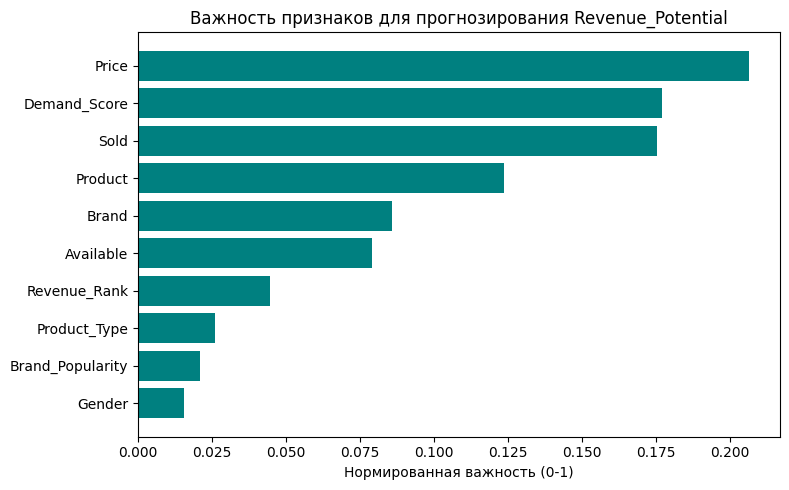

In [13]:
# =============================================
# БЛОК 13: ВАЖНОСТЬ ПРИЗНАКОВ
# =============================================
try:
    # Получаем важность из лучшей модели AutoML
    if hasattr(automl_reg.model.estimator, 'feature_importances_'):
        imp = automl_reg.model.estimator.feature_importances_
    else:
        imp = np.abs(df_clean[scale_cols].corrwith(df_clean[target]).values)

    # НОРМИРУЕМ ВАЖНОСТЬ (сумма = 1)
    imp_norm = imp / imp.sum()

    # Создаем DataFrame с нормированной важностью
    imp_df = pd.DataFrame({
        'Признак': X.columns,
        'Важность': imp_norm,
        'Важность_абс': imp  # сохраняем исходные значения для справки
    }).sort_values('Важность', ascending=False)

    # Вывод таблицы
    print("\nНОРМИРОВАННАЯ ВАЖНОСТЬ ПРИЗНАКОВ:")
    print("="*50)
    print(imp_df[['Признак', 'Важность']].head(10).to_string(index=False))

    print("\nАБСОЛЮТНЫЕ ЗНАЧЕНИЯ ВАЖНОСТИ (для справки):")
    print("="*50)
    print(imp_df[['Признак', 'Важность_абс']].head(10).to_string(index=False))

    # График
    plt.figure(figsize=(8, 5))
    plt.barh(imp_df.head(10)['Признак'], imp_df.head(10)['Важность'], color='teal')
    plt.xlabel('Нормированная важность (0-1)')
    plt.title('Важность признаков для прогнозирования Revenue_Potential')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Не удалось получить важность признаков: {e}")